In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

In [ ]:
spark = SparkSession.builder \
    .appName("Titanic EDA") \
    .master("local[*]") \
    .getOrCreate()


In [ ]:
df = spark.read.csv(
    "/content/train.csv",
    header=True,
    inferSchema=True
)

In [ ]:
df.show()

+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|          Ticket|   Fare|Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|          1|       0|     3|Braund, Mr. Owen ...|  male|22.0|    1|    0|       A/5 21171|   7.25| NULL|       S|
|          2|       1|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|        PC 17599|71.2833|  C85|       C|
|          3|       1|     3|Heikkinen, Miss. ...|female|26.0|    0|    0|STON/O2. 3101282|  7.925| NULL|       S|
|          4|       1|     1|Futrelle, Mrs. Ja...|female|35.0|    1|    0|          113803|   53.1| C123|       S|
|          5|       0|     3|Allen, Mr. Willia...|  male|35.0|    0|    0|          373450|   8.05| NULL|       S|
|          6|       0|     3|    Moran, Mr. James|  male|NULL|    0|    0|      

In [ ]:
df.printSchema()

root
 |-- PassengerId: integer (nullable = true)
 |-- Survived: integer (nullable = true)
 |-- Pclass: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Sex: string (nullable = true)
 |-- Age: double (nullable = true)
 |-- SibSp: integer (nullable = true)
 |-- Parch: integer (nullable = true)
 |-- Ticket: string (nullable = true)
 |-- Fare: double (nullable = true)
 |-- Cabin: string (nullable = true)
 |-- Embarked: string (nullable = true)



In [ ]:
df.count()

891

In [ ]:
len(df.columns)

12

In [ ]:
df.columns

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [ ]:
df.describe().show()

+-------+-----------------+-------------------+------------------+--------------------+------+------------------+------------------+-------------------+------------------+-----------------+-----+--------+
|summary|      PassengerId|           Survived|            Pclass|                Name|   Sex|               Age|             SibSp|              Parch|            Ticket|             Fare|Cabin|Embarked|
+-------+-----------------+-------------------+------------------+--------------------+------+------------------+------------------+-------------------+------------------+-----------------+-----+--------+
|  count|              891|                891|               891|                 891|   891|               714|               891|                891|               891|              891|  204|     889|
|   mean|            446.0| 0.3838383838383838| 2.308641975308642|                NULL|  NULL| 29.69911764705882|0.5230078563411896|0.38159371492704824|260318.54916792738| 32.20420

In [ ]:
df.select([
    count(when(col(C).isNull(), C)).alias(C)
    for C in df.columns
]).show()

+-----------+--------+------+----+---+---+-----+-----+------+----+-----+--------+
|PassengerId|Survived|Pclass|Name|Sex|Age|SibSp|Parch|Ticket|Fare|Cabin|Embarked|
+-----------+--------+------+----+---+---+-----+-----+------+----+-----+--------+
|          0|       0|     0|   0|  0|177|    0|    0|     0|   0|  687|       2|
+-----------+--------+------+----+---+---+-----+-----+------+----+-----+--------+



In [ ]:
print("Toatal:", df.count())
print("Distinct:",df.distinct().count())


Toatal: 891
Distinct: 891


In [ ]:
df.dtypes

[('PassengerId', 'int'),
 ('Survived', 'int'),
 ('Pclass', 'int'),
 ('Name', 'string'),
 ('Sex', 'string'),
 ('Age', 'double'),
 ('SibSp', 'int'),
 ('Parch', 'int'),
 ('Ticket', 'string'),
 ('Fare', 'double'),
 ('Cabin', 'string'),
 ('Embarked', 'string')]

In [ ]:
df.filter(
    col("Age")>50).show()

+-----------+--------+------+--------------------+------+----+-----+-----+-----------+--------+-----+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|     Ticket|    Fare|Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+-----------+--------+-----+--------+
|          7|       0|     1|McCarthy, Mr. Tim...|  male|54.0|    0|    0|      17463| 51.8625|  E46|       S|
|         12|       1|     1|Bonnell, Miss. El...|female|58.0|    0|    0|     113783|   26.55| C103|       S|
|         16|       1|     2|Hewlett, Mrs. (Ma...|female|55.0|    0|    0|     248706|    16.0| NULL|       S|
|         34|       0|     2|Wheadon, Mr. Edwa...|  male|66.0|    0|    0| C.A. 24579|    10.5| NULL|       S|
|         55|       0|     1|Ostby, Mr. Engelh...|  male|65.0|    0|    1|     113509| 61.9792|  B30|       C|
|         95|       0|     3|   Coxon, Mr. Daniel|  male|59.0|    0|    0|     364500|    7.25| NULL|       S|
|

In [ ]:
df.filter(
    col("Sex")=="female"
).show()


+-----------+--------+------+--------------------+------+----+-----+-----+----------------+--------+-----+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|          Ticket|    Fare|Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+----------------+--------+-----+--------+
|          2|       1|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|        PC 17599| 71.2833|  C85|       C|
|          3|       1|     3|Heikkinen, Miss. ...|female|26.0|    0|    0|STON/O2. 3101282|   7.925| NULL|       S|
|          4|       1|     1|Futrelle, Mrs. Ja...|female|35.0|    1|    0|          113803|    53.1| C123|       S|
|          9|       1|     3|Johnson, Mrs. Osc...|female|27.0|    0|    2|          347742| 11.1333| NULL|       S|
|         10|       1|     2|Nasser, Mrs. Nich...|female|14.0|    1|    0|          237736| 30.0708| NULL|       C|
|         11|       1|     3|Sandstrom, Miss. ...|female| 4.0|    1|    

In [ ]:
df.filter(
    (col("Sex")=="female") &
    (col("Survived")==1)
).show()


+-----------+--------+------+--------------------+------+----+-----+-----+----------------+--------+-----+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|          Ticket|    Fare|Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+----------------+--------+-----+--------+
|          2|       1|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|        PC 17599| 71.2833|  C85|       C|
|          3|       1|     3|Heikkinen, Miss. ...|female|26.0|    0|    0|STON/O2. 3101282|   7.925| NULL|       S|
|          4|       1|     1|Futrelle, Mrs. Ja...|female|35.0|    1|    0|          113803|    53.1| C123|       S|
|          9|       1|     3|Johnson, Mrs. Osc...|female|27.0|    0|    2|          347742| 11.1333| NULL|       S|
|         10|       1|     2|Nasser, Mrs. Nich...|female|14.0|    1|    0|          237736| 30.0708| NULL|       C|
|         11|       1|     3|Sandstrom, Miss. ...|female| 4.0|    1|    

In [ ]:
df.orderBy(
    col("Fare").desc()
).show()

+-----------+--------+------+--------------------+------+----+-----+-----+--------+--------+---------------+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|  Ticket|    Fare|          Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+--------+--------+---------------+--------+
|        259|       1|     1|    Ward, Miss. Anna|female|35.0|    0|    0|PC 17755|512.3292|           NULL|       C|
|        680|       1|     1|Cardeza, Mr. Thom...|  male|36.0|    0|    1|PC 17755|512.3292|    B51 B53 B55|       C|
|        738|       1|     1|Lesurer, Mr. Gust...|  male|35.0|    0|    0|PC 17755|512.3292|           B101|       C|
|         28|       0|     1|Fortune, Mr. Char...|  male|19.0|    3|    2|   19950|   263.0|    C23 C25 C27|       S|
|         89|       1|     1|Fortune, Miss. Ma...|female|23.0|    3|    2|   19950|   263.0|    C23 C25 C27|       S|
|        342|       1|     1|Fortune, Miss. Al...|female

In [ ]:
df.orderBy(
    col("Age").desc()
).show()


+-----------+--------+------+--------------------+------+----+-----+-----+-----------+-------+-----------+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|     Ticket|   Fare|      Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+-----------+-------+-----------+--------+
|        631|       1|     1|Barkworth, Mr. Al...|  male|80.0|    0|    0|      27042|   30.0|        A23|       S|
|        852|       0|     3| Svensson, Mr. Johan|  male|74.0|    0|    0|     347060|  7.775|       NULL|       S|
|         97|       0|     1|Goldschmidt, Mr. ...|  male|71.0|    0|    0|   PC 17754|34.6542|         A5|       C|
|        494|       0|     1|Artagaveytia, Mr....|  male|71.0|    0|    0|   PC 17609|49.5042|       NULL|       C|
|        117|       0|     3|Connors, Mr. Patrick|  male|70.5|    0|    0|     370369|   7.75|       NULL|       Q|
|        673|       0|     2|Mitchell, Mr. Hen...|  male|70.0|    0|    

In [ ]:
df.groupBy("Sex").count().show()


+------+-----+
|   Sex|count|
+------+-----+
|female|  314|
|  male|  577|
+------+-----+



In [ ]:
df.groupBy("Pclass").agg(
    avg("Fare").alias("Avearge Fare")
).show()

+------+------------------+
|Pclass|      Avearge Fare|
+------+------------------+
|     1| 84.15468749999992|
|     3|13.675550101832997|
|     2| 20.66218315217391|
+------+------------------+



In [ ]:
df=df.withColumn(
    "FamilySize",
    col("SibSp")+col("Parch")+1
)
df.show()

+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+----------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|          Ticket|   Fare|Cabin|Embarked|FamilySize|
+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+----------+
|          1|       0|     3|Braund, Mr. Owen ...|  male|22.0|    1|    0|       A/5 21171|   7.25| NULL|       S|         2|
|          2|       1|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|        PC 17599|71.2833|  C85|       C|         2|
|          3|       1|     3|Heikkinen, Miss. ...|female|26.0|    0|    0|STON/O2. 3101282|  7.925| NULL|       S|         1|
|          4|       1|     1|Futrelle, Mrs. Ja...|female|35.0|    1|    0|          113803|   53.1| C123|       S|         2|
|          5|       0|     3|Allen, Mr. Willia...|  male|35.0|    0|    0|          373450|   8.05| NULL|       S|    

In [ ]:
df.stat.corr(
    "Age",
    "Fare"
)

0.135515853527051

In [ ]:
df.write.mode("overwrite") \
.option("header",True) \
.csv("Titanic_clean")

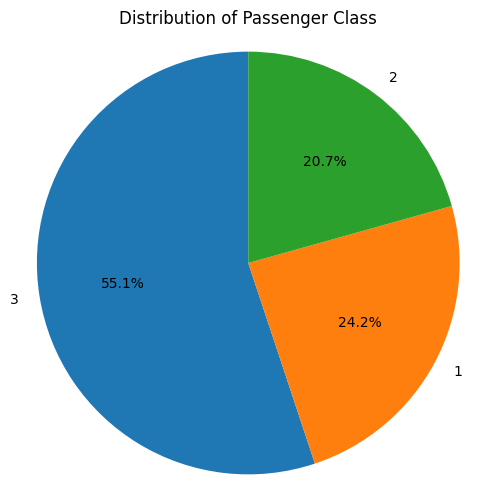

In [ ]:
# Calculate the value counts for 'Pclass'
pclass_counts = pdf['Pclass'].value_counts()

# Create a pie chart
plt.figure(figsize=(6, 6))
plt.pie(pclass_counts, labels=pclass_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Passenger Class')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
pdf=df.toPandas()

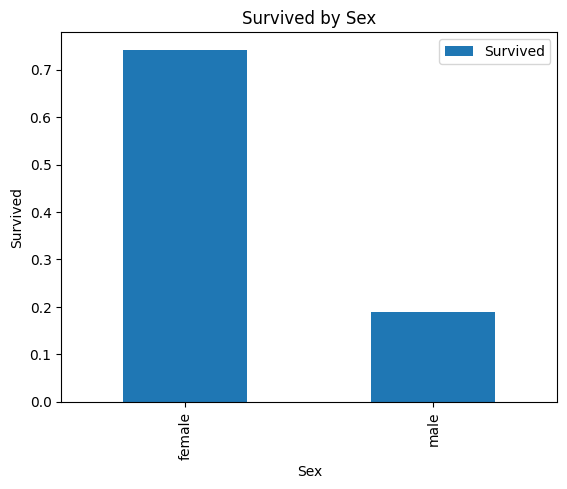

In [ ]:
pd.DataFrame(pdf.groupby("Sex")["Survived"].mean()).plot(kind="bar")
plt.title("Survived by Sex")
plt.xlabel("Sex")
plt.ylabel("Survived")
plt.show()

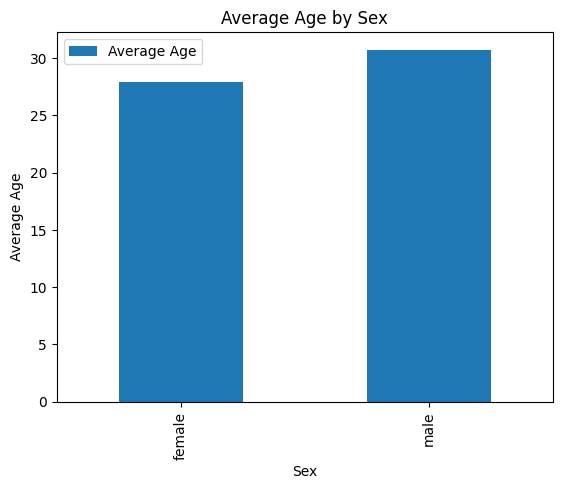

In [ ]:
import matplotlib.pyplot as plt

# Perform aggregation using Spark
avg_age_by_sex_spark = df.groupBy("Sex").agg(avg("Age").alias("Average Age"))

# Convert to Pandas DataFrame for plotting
avg_age_by_sex_pd = avg_age_by_sex_spark.toPandas()

avg_age_by_sex_pd.plot(kind="bar", x="Sex", y="Average Age")
plt.title("Average Age by Sex")
plt.xlabel("Sex")
plt.ylabel("Average Age")
plt.show()

In [ ]:
# Calculate the value counts for 'Pclass'
pclass_counts = pdf['Pclass'].value_counts()
survival_counts = pdf['Pclass'].value_counts()
# Create a pie chart
plt.figure(figsize=(6, 6))
plt.pie(pclass_counts,survival_counts labels=pclass_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Passenger Class')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()